# **Código en python para el análisis de ECG**
Ejemplo de código para análisis de señal ECG: Filtros y espectro de potencia.
## **Resultados para la Prueba 3: Post Ejercicio (actividad física aeróbica)**
### **Importación de librerías y parámetros del BITalino**

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch

# Parámetros del BITalino
Fs = 1000         # Hz
VCC = 3.3         # V referencia ADC
ADCres = 1023     # 10 bits
GAIN_ECG = 1100   # ganancia

### **Carga y conversión ADC -> mV**
Los datos del BITalino están en cuentas digitales (0–1023), por lo que convierten a milivoltios usando la fórmula del datasheet.

In [11]:
# Carga y conversión ADC -> mV
ecg_adc = np.loadtxt("Señales bitalino/ecg_ejercicio.txt", usecols=[-1])
ecg_V  = ((ecg_adc / ADCres) - 0.5) * VCC / GAIN_ECG
ecg_mV = ecg_V * 1000 

### **Ajustar intervalo de muestra y eliminación de componente DC**
Se define el intervalo de muestra y se elimina la componente DC antes del filtrado de la señal.

In [12]:
# Intervalo de muestra de interés: 5.7 a 8.7 seg (post ejercicio)
i0, i1 = int(5.7*Fs), int(8.7*Fs)
x  = ecg_mV[i0:i1]
t  = np.arange(i0, i1) / Fs

# Eliminar componente DC
x = x - np.mean(x)

### **Filtro pasa-banda (0.5 – 40 Hz)**
Elimina efectos de baja frecuencia como los generados por respiración o movimientos de electrodos, y de alta frecuencia como el ruido muscular o interferencias. Preserva las frecuencias donde están las ondas P, QRS y T.

In [13]:
# Filtro: pasa-banda (0.5 – 40 Hz)
b_bp, a_bp = butter(4, [0.5/(Fs/2), 40/(Fs/2)], btype="band")
x_bp = filtfilt(b_bp, a_bp, x)

### **Filtro Notch (60 Hz)**
Suprime el ruido eléctrico proveniente de la red eléctrica, que suele contaminar la señal.

In [14]:
# Filtro: notch (60 Hz)
b_n, a_n = iirnotch(60, Q=30, fs=Fs)  # red de 60 Hz
x_filt = filtfilt(b_n, a_n, x_bp)

### **Espectro de potencia (Welch)**
Permite observar cómo se distribuye la energía de la señal en el dominio de frecuencia. Es útil para confirmar que la mayor energía del ECG está en bajas frecuencias y que los filtros eliminaron ruido.

In [15]:
# Espectro de potencia (Welch)
nper = min(2048, len(x_filt))
f, Pxx = welch(x_filt - np.mean(x_filt), fs=Fs, nperseg=nper)

### **Generación de gráficas**
Se plotean 3 gráficas: la señal cruda, la señal post filtrado y el espectro de potencia (Welch).

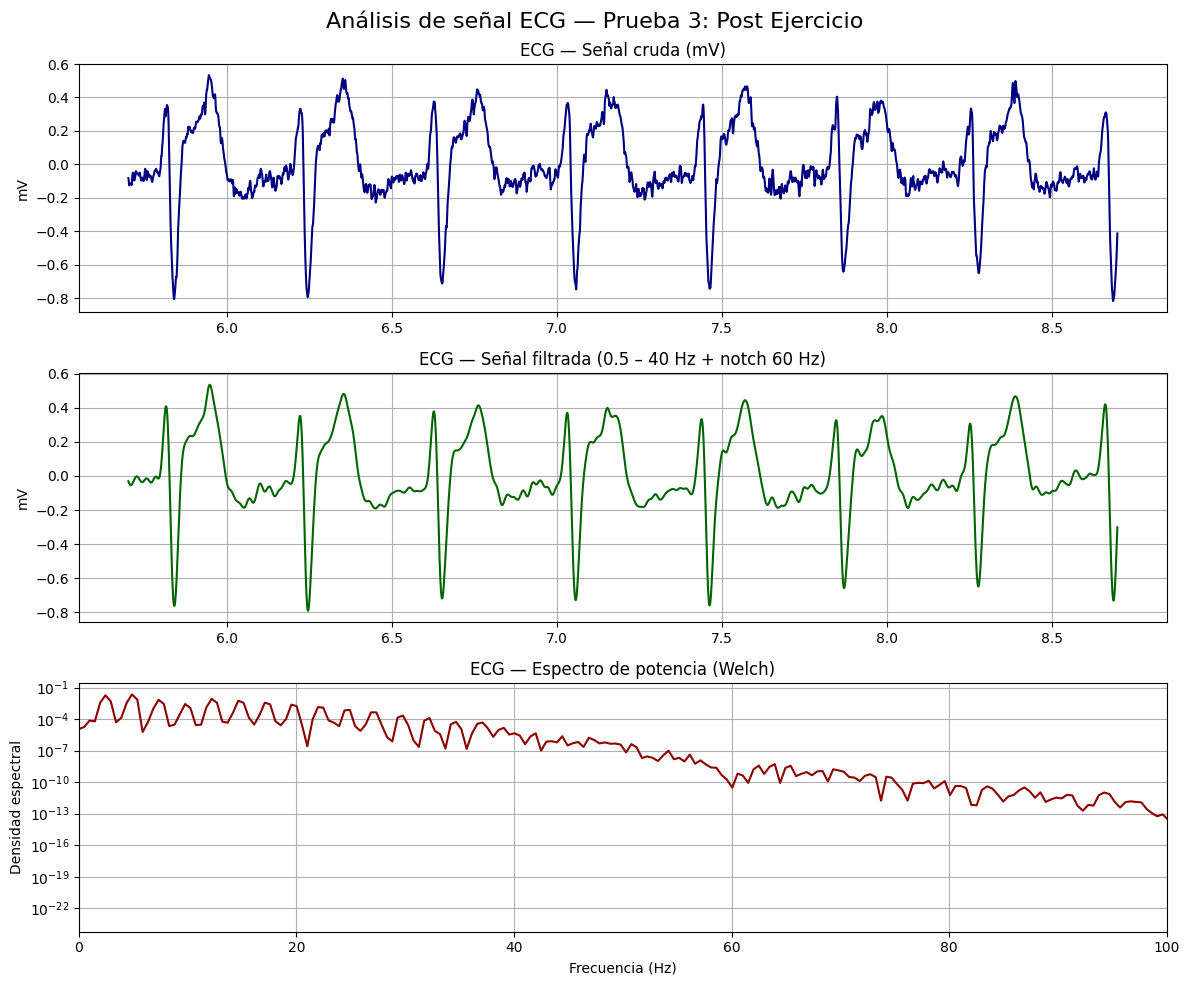

In [16]:
# Gráficas
plt.figure(figsize=(12, 10))
plt.suptitle("Análisis de señal ECG — Prueba 3: Post Ejercicio", fontsize=16)

# 1) Señal cruda
plt.subplot(3,1,1)
plt.plot(t, x, color="navy")
plt.title("ECG — Señal cruda (mV)")
plt.ylabel("mV"); plt.grid(True)

# 2) Señal con filtros (pasa-banda 0.5 – 40 Hz + notch 60 Hz)
plt.subplot(3,1,2)
plt.plot(t, x_filt, color="darkgreen")
plt.title("ECG — Señal filtrada (0.5 – 40 Hz + notch 60 Hz)")
plt.ylabel("mV"); plt.grid(True)

# 3) Espectro de potencia (Welch)
plt.subplot(3,1,3)
plt.semilogy(f, Pxx, color="darkred")
plt.title("ECG — Espectro de potencia (Welch)")
plt.xlabel("Frecuencia (Hz)"); plt.ylabel("Densidad espectral"); plt.grid(True)
plt.xlim(0, 100)  # ECG relevante < 40 Hz

plt.tight_layout()
plt.show()

### **Código completo**

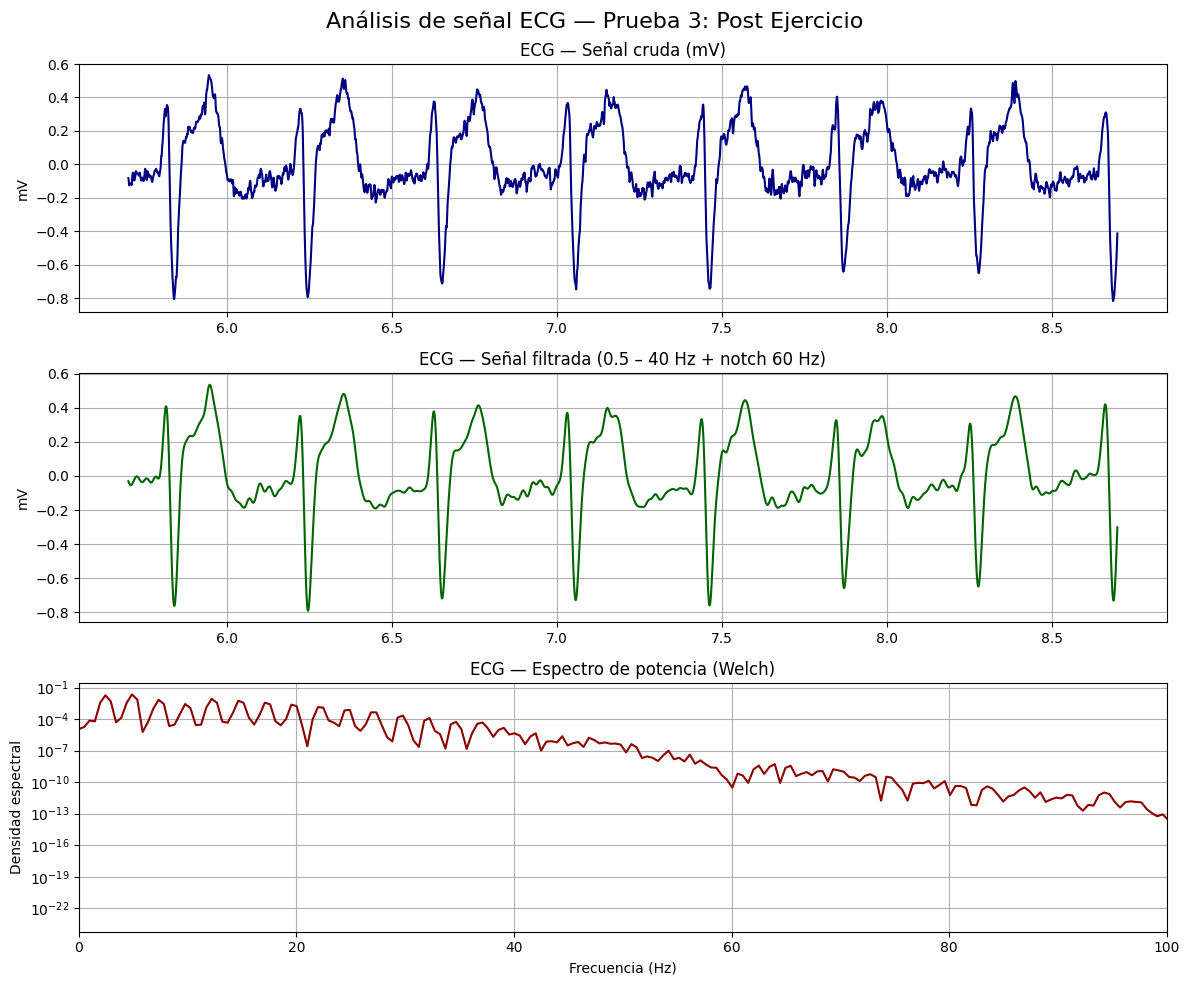

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch

# Parámetros del BITalino
Fs = 1000         # Hz
VCC = 3.3         # V referencia ADC
ADCres = 1023     # 10 bits
GAIN_ECG = 1100   # ganancia

# Carga y conversión ADC -> mV
ecg_adc = np.loadtxt("Señales bitalino/ecg_ejercicio.txt", usecols=[-1])
ecg_V  = ((ecg_adc / ADCres) - 0.5) * VCC / GAIN_ECG
ecg_mV = ecg_V * 1000 

# Intervalo de muestra de interés: 5.7 a 8.7 seg (post ejercicio)
i0, i1 = int(5.7*Fs), int(8.7*Fs)
x  = ecg_mV[i0:i1]
t  = np.arange(i0, i1) / Fs

# Eliminar componente DC
x = x - np.mean(x)

# Filtro: pasa-banda (0.5 – 40 Hz)
b_bp, a_bp = butter(4, [0.5/(Fs/2), 40/(Fs/2)], btype="band")
x_bp = filtfilt(b_bp, a_bp, x)

# Filtro: notch (60 Hz)
b_n, a_n = iirnotch(60, Q=30, fs=Fs)  # red de 60 Hz
x_filt = filtfilt(b_n, a_n, x_bp)

# Espectro de potencia (Welch)
nper = min(2048, len(x_filt))
f, Pxx = welch(x_filt - np.mean(x_filt), fs=Fs, nperseg=nper)

# Gráficas
plt.figure(figsize=(12, 10))
plt.suptitle("Análisis de señal ECG — Prueba 3: Post Ejercicio", fontsize=16)

# 1) Señal cruda
plt.subplot(3,1,1)
plt.plot(t, x, color="navy")
plt.title("ECG — Señal cruda (mV)")
plt.ylabel("mV"); plt.grid(True)

# 2) Señal con filtros (pasa-banda 0.5 – 40 Hz + notch 60 Hz)
plt.subplot(3,1,2)
plt.plot(t, x_filt, color="darkgreen")
plt.title("ECG — Señal filtrada (0.5 – 40 Hz + notch 60 Hz)")
plt.ylabel("mV"); plt.grid(True)

# 3) Espectro de potencia (Welch)
plt.subplot(3,1,3)
plt.semilogy(f, Pxx, color="darkred")
plt.title("ECG — Espectro de potencia (Welch)")
plt.xlabel("Frecuencia (Hz)"); plt.ylabel("Densidad espectral"); plt.grid(True)
plt.xlim(0, 100)  # ECG relevante < 40 Hz

plt.tight_layout()
plt.show()